# 06 - Dashboard Professionnel - Guide & Demonstration
## CEET Smart Grid - Energy Blackout Prediction
**Objectif :** Documenter et tester le dashboard Dash et l'API FastAPI.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import json
from utils import DATA_PROC

print("=== SERVICES DISPONIBLES ===")
print("  Dashboard Dash  : http://localhost:8050")
print("  API FastAPI     : http://localhost:8000")
print("  Docs Swagger    : http://localhost:8000/docs")
print("  App Streamlit   : http://localhost:8501")

=== SERVICES DISPONIBLES ===
  Dashboard Dash  : http://localhost:8050
  API FastAPI     : http://localhost:8000
  Docs Swagger    : http://localhost:8000/docs
  App Streamlit   : http://localhost:8501


### 6.1 Commandes de Lancement

In [2]:
launch_info = {
    "Dash Dashboard": "cd dashboard && python app.py",
    "FastAPI API":    "cd deployment/fastapi && uvicorn main:app --reload",
    "Streamlit App":  "cd deployment/streamlit && streamlit run app.py",
    "Docker Build":   "docker-compose -f deployment/docker/docker-compose.yml up --build",
}

for service, cmd in launch_info.items():
    print(f"  {service:20s}: {cmd}")

  Dash Dashboard      : cd dashboard && python app.py
  FastAPI API         : cd deployment/fastapi && uvicorn main:app --reload
  Streamlit App       : cd deployment/streamlit && streamlit run app.py
  Docker Build        : docker-compose -f deployment/docker/docker-compose.yml up --build


### 6.2 Simulation Locale de Prediction

In [3]:
def predict_local(reading):
    load_ratio   = reading['total_load_mw'] / max(reading['available_power_mw'], 1)
    power_margin = reading['available_power_mw'] - reading['total_load_mw']
    volt_dev     = abs(reading['voltage'] - 220)
    freq_dev     = abs(reading['frequency'] - 50)
    grid_stress  = (
        0.40 * min(load_ratio, 2) / 2 +
        0.30 * (reading['transformer_temp'] / 120) +
        0.15 * (volt_dev / 40) +
        0.15 * (freq_dev / 3)
    )
    event_factor = 1.15 if reading.get('event','') not in ['No Event',''] else 1.0
    risk = min((
        reading.get('outage_risk', 50)/100 * 0.35 +
        min(load_ratio, 2)/2 * 0.30 +
        grid_stress * 0.20 +
        reading['transformer_temp']/120 * 0.15
    ) * event_factor, 1.0)

    level = ("CRITIQUE" if risk >= 0.75 else
             "ELEVE"    if risk >= 0.50 else
             "MODERE"   if risk >= 0.25 else "FAIBLE")
    return {
        "prediction": int(risk >= 0.5),
        "probability_pct": round(risk * 100, 2),
        "risk_level": level,
        "load_ratio": round(load_ratio, 3),
        "power_margin_mw": round(power_margin, 1),
        "grid_stress_pct": round(grid_stress * 100, 2),
    }

# Test
test = {
    "total_load_mw": 420, "available_power_mw": 360,
    "temperature": 38, "transformer_temp": 92,
    "voltage": 208, "frequency": 49.5,
    "outage_risk": 85, "event": "Football Match"
}
result = predict_local(test)
print("=== PREDICTION ===")
for k, v in result.items():
    print(f"  {k:22s}: {v}")

=== PREDICTION ===
  prediction            : 1
  probability_pct       : 79.83
  risk_level            : CRITIQUE
  load_ratio            : 1.167
  power_margin_mw       : -60
  grid_stress_pct       : 53.33


### 6.3 Test Multi-Scenarios

          Scenario  probability_pct risk_level  load_ratio
        Nuit calme            18.14     FAIBLE       0.343
      Matin normal            39.00     MODERE       0.800
       Pointe soir            62.33      ELEVE       1.086
    Match football            83.96   CRITIQUE       1.257
Surcharge critique            96.12   CRITIQUE       1.486


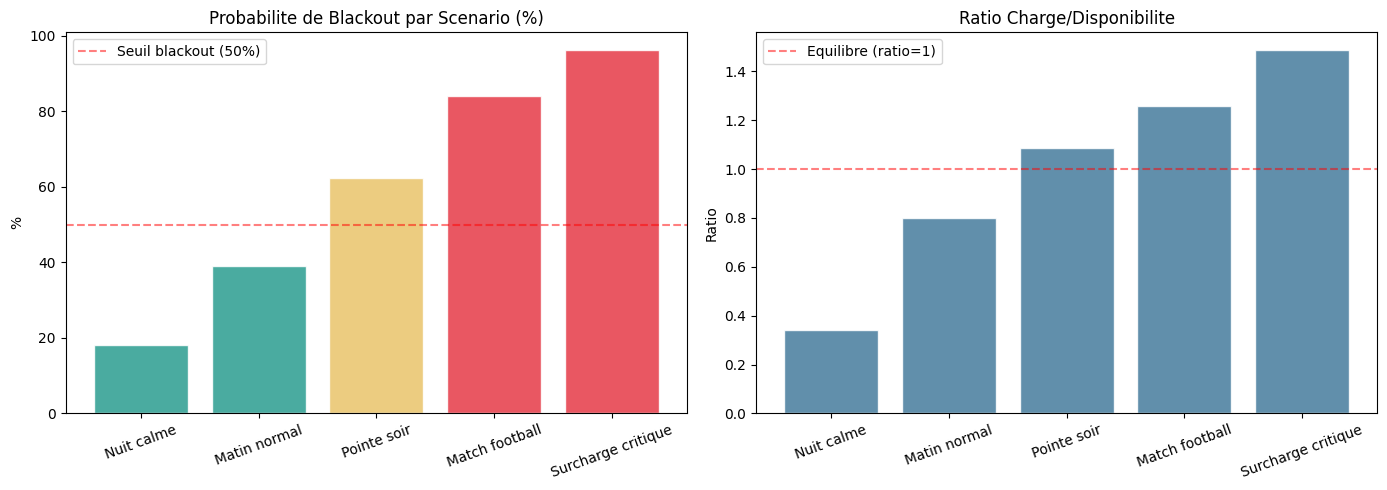

In [ ]:
import matplotlib.pyplot as plt

scenarios = [
    {"name": "Nuit calme", "total_load_mw": 120, "available_power_mw": 350,
     "transformer_temp": 45, "voltage": 222, "frequency": 50.1, "outage_risk": 10, "event": "No Event"},
    {"name": "Matin normal",      "total_load_mw": 280, "available_power_mw": 350,
     "transformer_temp": 65, "voltage": 219, "frequency": 49.9, "outage_risk": 35, "event": "No Event"},
    {"name": "Pointe soir",       "total_load_mw": 380, "available_power_mw": 350,
     "transformer_temp": 88, "voltage": 212, "frequency": 49.5, "outage_risk": 72, "event": "No Event"},
    {"name": "Match football",    "total_load_mw": 440, "available_power_mw": 350,
     "transformer_temp": 95, "voltage": 208, "frequency": 49.2, "outage_risk": 88, "event": "Football"},
    {"name": "Surcharge critique","total_load_mw": 520, "available_power_mw": 350,
     "transformer_temp": 110,"voltage": 198, "frequency": 48.8, "outage_risk": 95, "event": "Festival"},
]

results_list = []
for s in scenarios:
    r = predict_local(s)
    results_list.append({"Scenario": s['name'], **r})

df_sc = pd.DataFrame(results_list)
print(df_sc[['Scenario','probability_pct','risk_level','load_ratio']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2A9D8F' if p < 50 else '#E9C46A' if p < 75 else '#E63946'
          for p in df_sc['probability_pct']]
axes[0].bar(df_sc['Scenario'], df_sc['probability_pct'], color=colors, edgecolor='white', alpha=0.85)
axes[0].axhline(50, color='red', linestyle='--', alpha=0.5, label='Seuil blackout (50%)')
axes[0].set_title('Probabilite de Blackout par Scenario (%)')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

axes[1].bar(df_sc['Scenario'], df_sc['load_ratio'],
            color='#457B9D', edgecolor='white', alpha=0.85)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Equilibre (ratio=1)')
axes[1].set_title('Ratio Charge/Disponibilite')
axes[1].set_ylabel('Ratio')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/dashboard_scenarios.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.4 KPIs Globaux du Projet

In [5]:
df_full = pd.read_csv(DATA_PROC / 'ceet_processed.csv', parse_dates=['datetime'])

print("=" * 60)
print("  CEET SMART GRID - KPIs CLES DU PROJET")
print("=" * 60)
kpis = {
    "Periode analysee":         f"{df_full['datetime'].min().date()} a {df_full['datetime'].max().date()}",
    "Total observations":       f"{len(df_full):,}",
    "Taux de blackout":         f"{df_full['blackout'].mean()*100:.2f}%",
    "Taux de surcharge":        f"{df_full['overload'].mean()*100:.2f}%",
    "Delesage total (MW)":      f"{df_full['load_shedding_mw'].sum():,.0f}",
    "Charge moyenne (MW)":      f"{df_full['total_load_mw'].mean():.1f}",
    "Charge maximale (MW)":     f"{df_full['total_load_mw'].max():.1f}",
    "Risque moyen (%)":         f"{df_full['outage_risk'].mean():.1f}",
    "Region la + risquee":      df_full.groupby('region')['outage_risk'].mean().idxmax(),
    "Heure la + a risque":      f"{int(df_full.groupby('hour')['blackout'].mean().idxmax())}h",
    "Saison la + a risque":     df_full.groupby('season')['blackout'].mean().idxmax(),
    "Features totales":         str(df_full.shape[1]),
}
for k, v in kpis.items():
    print(f"  {k:35s}: {v}")

  CEET SMART GRID - KPIs CLES DU PROJET
  Periode analysee                   : 2020-01-01 a 2025-09-14
  Total observations                 : 50,000
  Taux de blackout                   : 3.95%
  Taux de surcharge                  : 82.47%
  Delesage total (MW)                : 718,632
  Charge moyenne (MW)                : 310.3
  Charge maximale (MW)               : 551.4
  Risque moyen (%)                   : 94.6
  Region la + risquee                : Lome
  Heure la + a risque                : 23h
  Saison la + a risque               : Pluvieuse
  Features totales                   : 75
